**Instalar librerias**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [2]:
# --- Cargar dataset ---
df = pd.read_csv("/content/datos.csv")

**Preparación**

In [3]:
target = "Salary"
features = [c for c in df.columns if c != target]

# Codificar variables categóricas
X = pd.get_dummies(df[features], drop_first=True)
y = df[target]

# División train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

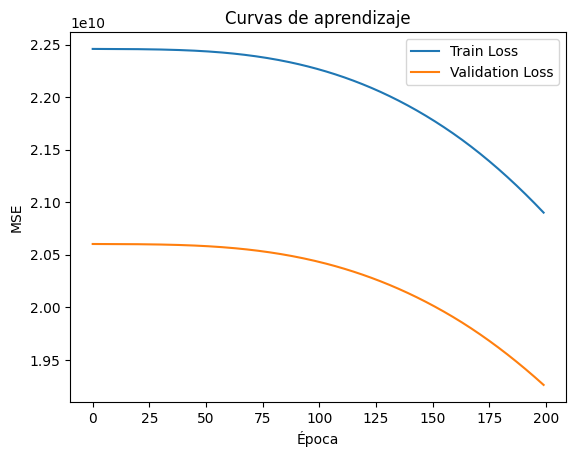

In [4]:
mlp = MLPRegressor(hidden_layer_sizes=(32,32), activation='relu', alpha=0.001,
                   max_iter=1, warm_start=True, random_state=42)

train_loss, val_loss = [], []
for epoch in range(1, 201):
    mlp.partial_fit(X_train_sc, y_train)
    y_train_pred = mlp.predict(X_train_sc)
    y_val_pred   = mlp.predict(X_val_sc)
    train_loss.append(mean_squared_error(y_train, y_train_pred))
    val_loss.append(mean_squared_error(y_val, y_val_pred))

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.title("Curvas de aprendizaje")
plt.show()

**Regulización (L2 vs Dropout)**

In [5]:
mlp_l2 = MLPRegressor(hidden_layer_sizes=(32,32), activation='relu', alpha=0.01, max_iter=500, random_state=42)
mlp_l2.fit(X_train_sc, y_train)
print("L2 → R² Val:", r2_score(y_val, mlp_l2.predict(X_val_sc)))

mlp_small = MLPRegressor(hidden_layer_sizes=(16,16), activation='relu', max_iter=500, random_state=42)
mlp_small.fit(X_train_sc, y_train)
print("Dropout simulado → R² Val:", r2_score(y_val, mlp_small.predict(X_val_sc)))

L2 → R² Val: -4.986738268861369
Dropout simulado → R² Val: -10.311613112793312


**Normalizar**

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

# --- Sin normalización ---
mlp_no_norm = MLPRegressor(hidden_layer_sizes=(32,32), activation='relu', max_iter=500, random_state=42)
mlp_no_norm.fit(X_train, y_train)
r2_no_norm = r2_score(y_val, mlp_no_norm.predict(X_val))

# --- Con normalización ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

mlp_norm = MLPRegressor(hidden_layer_sizes=(32,32), activation='relu', max_iter=500, random_state=42)
mlp_norm.fit(X_train_sc, y_train)
r2_norm = r2_score(y_val, mlp_norm.predict(X_val_sc))

print(f"R² sin normalización : {r2_no_norm:.4f}")
print(f"R² con normalización : {r2_norm:.4f}")

R² sin normalización : -0.4295
R² con normalización : -4.9867


In [7]:
best_val = float("inf")
best_epoch = 0
mlp_es = MLPRegressor(hidden_layer_sizes=(32,32), activation='relu', alpha=0.001,
                      max_iter=1, warm_start=True, random_state=42)

for epoch in range(1, 201):
    mlp_es.partial_fit(X_train_sc, y_train)
    val_loss = mean_squared_error(y_val, mlp_es.predict(X_val_sc))
    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch

print("Early Stopping se detuvo en época:", best_epoch)

Early Stopping se detuvo en época: 200


**Empaquetar el modelo**

In [8]:
import joblib

pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(hidden_layer_sizes=(32,32), activation='relu', alpha=0.001,
                         max_iter=500, random_state=42))
])

pipeline_final.fit(X, y)
joblib.dump(pipeline_final, "modelo_final.pkl")

['modelo_final.pkl']

In [9]:
# predict.py
import pandas as pd
import joblib

modelo = joblib.load("modelo_final.pkl")
df_inf = pd.read_csv("/content/data_inference.csv")
X_inf = pd.get_dummies(df_inf.drop(columns=["Salary"]), drop_first=True)

preds = modelo.predict(X_inf)
df_out = pd.DataFrame({"ID": df_inf.index, "Predicted_Salary": preds})
df_out.to_csv("predictions.csv", index=False)
print("Predicciones guardadas en predictions.csv")

Predicciones guardadas en predictions.csv
